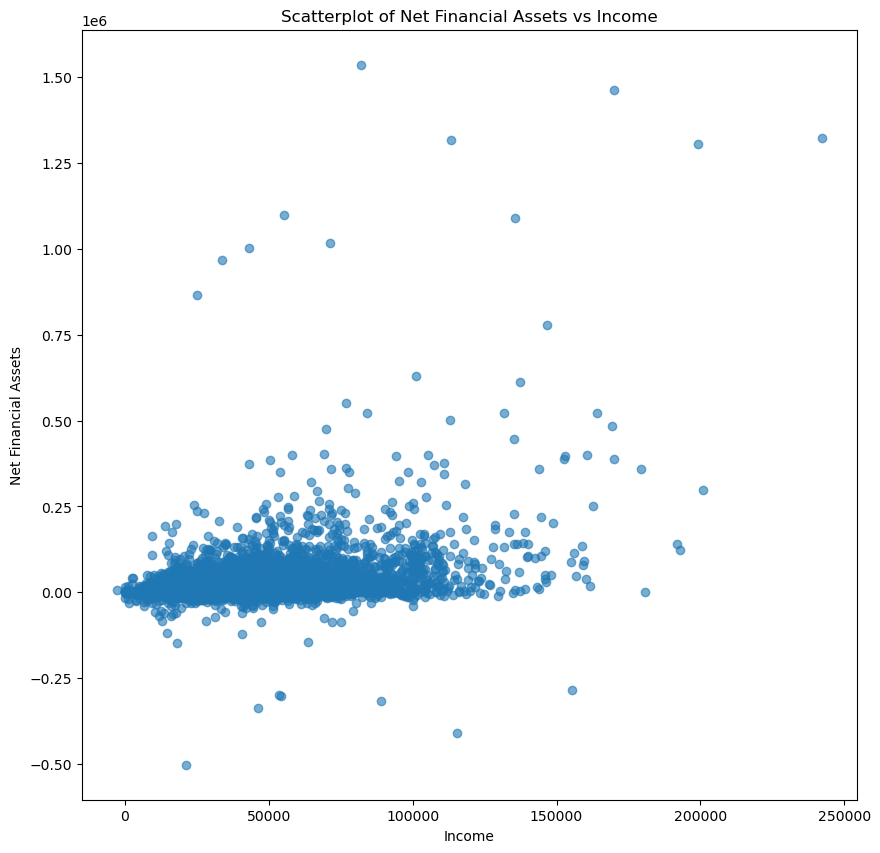

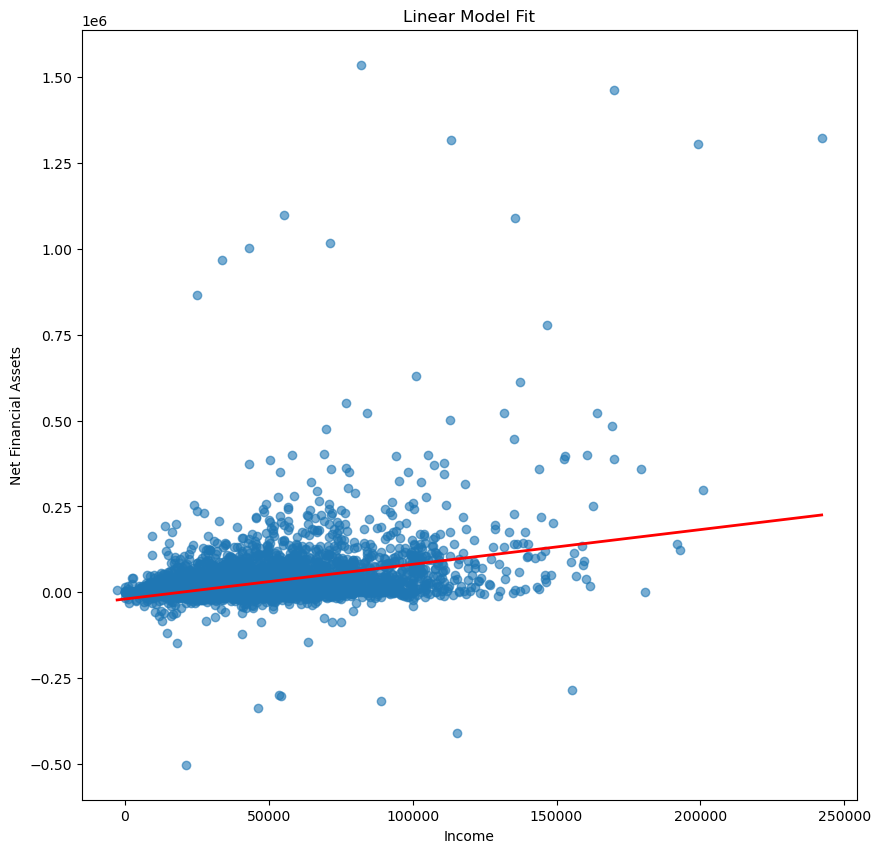

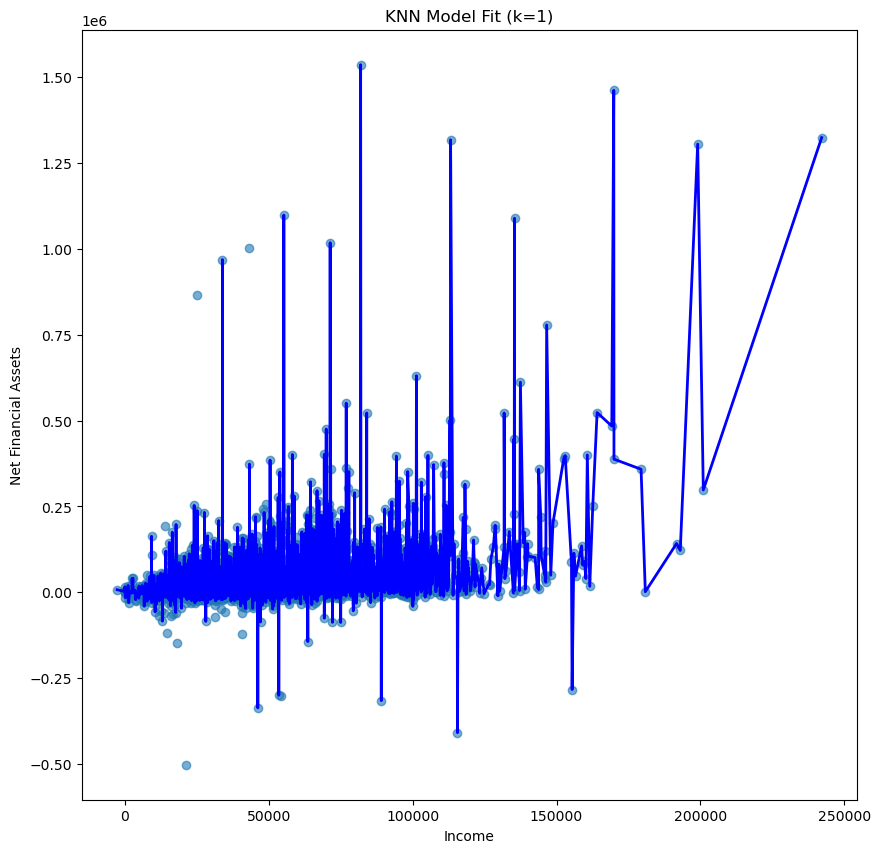

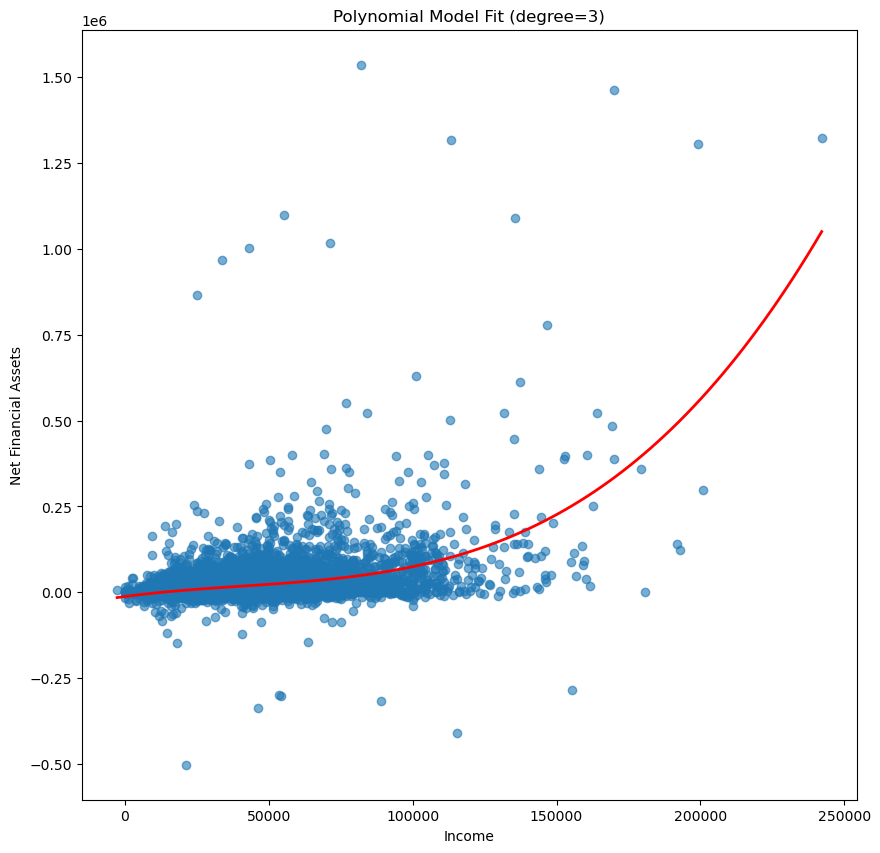

Model Comparison Results:
                          Linear     Overfit  Polynomial
RMSE (in-sample)      59034.8039  24126.4721  56724.7247
RMSE (out-of-sample)  56469.2451  79247.1552  55399.1421
R2 (in-sample)            0.1542      0.8587      0.2191
R2 (out-of-sample)        0.1325     -0.7084      0.1651

Sum of Squared Errors by Fold:
             Linear       Overfit    Polynomial
Fold1  2.639412e+12  6.545509e+12  2.566483e+12
Fold2  6.593280e+12  1.468419e+13  5.960942e+12
Fold3  3.674133e+12  7.260793e+12  3.787866e+12
Fold4  4.178420e+12  1.160651e+13  3.385578e+12
Fold5  1.087314e+13  1.374023e+13  1.036673e+13

Cross-Validation RMSE:
Linear: 59116.8217
Overfit: 82034.4745
Polynomial: 57082.8327

Final Model Performance Comparison (R²):
            Linear    KNN  Polynomial
CV Average   0.133 -0.463       0.165
Refit        0.133 -0.708       0.165


In [1]:
# Code for 401(k) example in Lecture notes 1 illustrating
# model assessment via validation

######################### Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
import warnings
import os
warnings.filterwarnings('ignore')

######################### Options
dpl = False     # switch to save plots. Set to False to just run code
#plotdir = os.path.abspath("../Slides/figures")

# Read data
#######################################################
data_path = os.path.join("..", "Data", "restatw.dat")
data401k = pd.read_csv(data_path, sep=r"\s+")

# Variables we care about are
# net total financial assets (net_tfa)
# 401(k) participation (p401)
# 401(k) eligibility (e401)
# income (inc)
# age (age)
# family size (fsize)
# years schooling (educ)
# marital status (marr)
# gender (male)
# two-earner household (twoearn)

########################## Estimation and testing sample
np.random.seed(8261977)
ntrain = 8000    # number of training observations
tr = np.random.choice(len(data401k), ntrain, replace=False)  # draw ntrain observations from original data
train = data401k.iloc[tr].copy()   # Training sample
test = data401k.iloc[~data401k.index.isin(tr)].copy()   # Testing sample

################################################################
########################## Scatterplot 
plt.figure(figsize=(10, 10))
plt.scatter(train['inc'], train['net_tfa'], alpha=0.6)
plt.xlabel("Income")
plt.ylabel("Net Financial Assets")
plt.title("Scatterplot of Net Financial Assets vs Income")
if dpl:
    plt.savefig(f'{plotdir}/ScPlNetTFA.png')
    plt.close()
else:
    plt.show()

########################## Linear model in income
plt.figure(figsize=(10, 10))
plt.scatter(train['inc'], train['net_tfa'], alpha=0.6)
plt.xlabel("Income")
plt.ylabel("Net Financial Assets")

# Fit linear model and plot line
lm_nettfa = LinearRegression()
X_train_lm = train[['inc']]
y_train = train['net_tfa']
lm_nettfa.fit(X_train_lm, y_train)

# Create smooth line for plotting
inc_range = np.linspace(train['inc'].min(), train['inc'].max(), 100)
lm_pred_line = lm_nettfa.predict(inc_range.reshape(-1, 1))
plt.plot(inc_range, lm_pred_line, color='red', linewidth=2)
plt.title("Linear Model Fit")

if dpl:
    plt.savefig(f'{plotdir}/LMNetTFA.png')
    plt.close()
else:
    plt.show()

# Linear regression results
X_test_lm = test[['inc']]
lm_yhat = lm_nettfa.predict(X_test_lm)  # out-of-sample prediction

lm_MSE = mean_squared_error(test['net_tfa'], lm_yhat)  # out-of-sample MSE
lm_RMSE = np.sqrt(lm_MSE)                              # out-of-sample RMSE
lm_OOSR2 = 1 - lm_MSE / np.mean((test['net_tfa'] - np.mean(train['net_tfa']))**2)  # out-of-sample R^2

########################## Vastly overfit KNN
tmp_train = train[['net_tfa', 'inc']].copy()   # Just keep the variables we want
tmp_test = test[['net_tfa', 'inc']].copy()     # Just keep the variables we want

# Sort by income to make plots easier
ind = np.argsort(tmp_train['inc'].values)
tmp_train = tmp_train.iloc[ind].copy()

# 1 nearest neighbor fit
knn_model = KNeighborsRegressor(n_neighbors=1, weights='uniform')
knn_model.fit(tmp_train[['inc']], tmp_train['net_tfa'])
knn_fitted = knn_model.predict(tmp_train[['inc']])

# Create plot data
knn_plot = pd.DataFrame({
    'net_tfa': tmp_train['net_tfa'].values,
    'inc': tmp_train['inc'].values,
    'fits': knn_fitted
})

# Plot KNN fit
plt.figure(figsize=(10, 10))
plt.scatter(train['inc'], train['net_tfa'], alpha=0.6)
plt.plot(knn_plot['inc'], knn_plot['fits'], color='blue', linewidth=2)
plt.xlabel("Income")
plt.ylabel("Net Financial Assets")
plt.title("KNN Model Fit (k=1)")

if dpl:
    plt.savefig(f'{plotdir}/KNNNetTFA.png')
    plt.close()
else:
    plt.show()

# In-sample R^2 for KNN
knnR2 = 1 - np.sum((knn_plot['net_tfa'] - knn_plot['fits'])**2) / np.sum((knn_plot['net_tfa'] - np.mean(knn_plot['net_tfa']))**2)

# Out-of-sample KNN predictions
knn_yhat = knn_model.predict(tmp_test[['inc']])  # out-of-sample fits
knn_MSE = mean_squared_error(tmp_test['net_tfa'], knn_yhat)  # out-of-sample MSE
knn_RMSE = np.sqrt(knn_MSE)                                  # out-of-sample RMSE
knn_OOSR2 = 1 - knn_MSE / np.mean((tmp_test['net_tfa'] - np.mean(train['net_tfa']))**2)  # out-of-sample R^2

########################### Sensible polynomial
# Create polynomial features pipeline
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=True)),
    ('linear', LinearRegression())
])

# Fit polynomial model
poly_model.fit(train[['inc']], train['net_tfa'])

# Plot polynomial fit
plt.figure(figsize=(10, 10))
plt.scatter(train['inc'], train['net_tfa'], alpha=0.6)

# Create smooth line for polynomial
inc_range = np.linspace(train['inc'].min(), train['inc'].max(), 100)
poly_pred_line = poly_model.predict(inc_range.reshape(-1, 1))
plt.plot(inc_range, poly_pred_line, color='red', linewidth=2)
plt.xlabel("Income")
plt.ylabel("Net Financial Assets")
plt.title("Polynomial Model Fit (degree=3)")

if dpl:
    plt.savefig(f'{plotdir}/PolyNetTFA.png')
    plt.close()
else:
    plt.show()

# Polynomial regression results
poly_yhat = poly_model.predict(test[['inc']])  # out-of-sample prediction

poly_MSE = mean_squared_error(test['net_tfa'], poly_yhat)  # out-of-sample MSE
poly_RMSE = np.sqrt(poly_MSE)                              # out-of-sample RMSE
poly_OOSR2 = 1 - poly_MSE / np.mean((test['net_tfa'] - np.mean(train['net_tfa']))**2)  # out-of-sample R^2

########################### Results
# Calculate in-sample RMSE
lm_train_pred = lm_nettfa.predict(train[['inc']])
lm_in_RMSE = np.sqrt(mean_squared_error(train['net_tfa'], lm_train_pred))

knn_in_RMSE = np.sqrt(np.mean((knn_plot['net_tfa'] - knn_plot['fits'])**2))

poly_train_pred = poly_model.predict(train[['inc']])
poly_in_RMSE = np.sqrt(mean_squared_error(train['net_tfa'], poly_train_pred))

in_RMSE = [lm_in_RMSE, knn_in_RMSE, poly_in_RMSE]  # in-sample RMSE
out_RMSE = [lm_RMSE, knn_RMSE, poly_RMSE]  # out-of-sample RMSE

# Calculate in-sample R^2
lm_in_R2 = r2_score(train['net_tfa'], lm_train_pred)
poly_in_R2 = r2_score(train['net_tfa'], poly_train_pred)

in_R2 = [lm_in_R2, knnR2, poly_in_R2]  # in-sample R2
out_R2 = [lm_OOSR2, knn_OOSR2, poly_OOSR2]  # out-of-sample R2

# Create results table
table = np.zeros((4, 3))
table[0, :] = in_RMSE
table[1, :] = out_RMSE
table[2, :] = in_R2
table[3, :] = out_R2

results_df = pd.DataFrame(table, 
                         columns=["Linear", "Overfit", "Polynomial"],
                         index=["RMSE (in-sample)", "RMSE (out-of-sample)", 
                               "R2 (in-sample)", "R2 (out-of-sample)"])
print("Model Comparison Results:")
print(results_df.round(4))

#############################################################################
############################# Brute force 5-fold CV
# Setup for brute force K-Fold CV
Kf = 5  # Number of folds
sampleframe = np.tile(np.arange(1, Kf + 1), int(np.ceil(ntrain / Kf)))
cvgroup = np.random.choice(sampleframe, size=ntrain, replace=False)  # CV groups
nTe = len(test)

# Compute squared forecast loss across folds
SSE = np.zeros((5, 3))
SSE_df = pd.DataFrame(SSE, 
                     columns=["Linear", "Overfit", "Polynomial"],
                     index=["Fold1", "Fold2", "Fold3", "Fold4", "Fold5"])

yhat_base = np.zeros((nTe, 5))
yhat_knn = np.zeros((nTe, 5))
yhat_poly = np.zeros((nTe, 5))

for k in range(1, Kf + 1):
    indk = cvgroup == k
    K_train = train[~indk].copy()
    K_test = train[indk].copy()
    
    # Linear model
    lm_cv = LinearRegression()
    lm_cv.fit(K_train[['inc']], K_train['net_tfa'])
    lm_cv_pred = lm_cv.predict(K_test[['inc']])
    SSE[k-1, 0] = np.sum((K_test['net_tfa'] - lm_cv_pred)**2)
    
    # KNN model
    knn_cv = KNeighborsRegressor(n_neighbors=1, weights='uniform')
    knn_cv.fit(K_train[['inc']], K_train['net_tfa'])
    knn_cv_pred = knn_cv.predict(K_test[['inc']])
    SSE[k-1, 1] = np.sum((K_test['net_tfa'] - knn_cv_pred)**2)
    
    # Polynomial model
    poly_cv = Pipeline([
        ('poly', PolynomialFeatures(degree=3, include_bias=True)),
        ('linear', LinearRegression())
    ])
    poly_cv.fit(K_train[['inc']], K_train['net_tfa'])
    poly_cv_pred = poly_cv.predict(K_test[['inc']])
    SSE[k-1, 2] = np.sum((K_test['net_tfa'] - poly_cv_pred)**2)
    
    # Store predictions on test set
    yhat_base[:, k-1] = lm_cv.predict(test[['inc']])
    yhat_knn[:, k-1] = knn_cv.predict(test[['inc']])
    yhat_poly[:, k-1] = poly_cv.predict(test[['inc']])

# Update SSE_df with computed values
SSE_df.iloc[:, :] = SSE
print("\nSum of Squared Errors by Fold:")
print(SSE_df.round(0))

# Summarize results across folds with RMSE
RMSE_cv = np.sqrt(np.sum(SSE, axis=0) / ntrain)
print(f"\nCross-Validation RMSE:")
print(f"Linear: {RMSE_cv[0]:.4f}")
print(f"Overfit: {RMSE_cv[1]:.4f}")
print(f"Polynomial: {RMSE_cv[2]:.4f}")

## Performance on validation data
# Prediction rule one - average cross-validated fits
r2_CVave_base = 1 - np.sum((test['net_tfa'] - np.mean(yhat_base, axis=1))**2) / \
                np.sum((test['net_tfa'] - np.mean(train['net_tfa']))**2)

r2_CVave_knn = 1 - np.sum((test['net_tfa'] - np.mean(yhat_knn, axis=1))**2) / \
               np.sum((test['net_tfa'] - np.mean(train['net_tfa']))**2)

r2_CVave_poly = 1 - np.sum((test['net_tfa'] - np.mean(yhat_poly, axis=1))**2) / \
                np.sum((test['net_tfa'] - np.mean(train['net_tfa']))**2)

# Prediction rule two - fit on entire (training) data set
# Already computed above as out_R2

# Create final comparison table
final_table = np.zeros((2, 3))
final_table[0, :] = [r2_CVave_base, r2_CVave_knn, r2_CVave_poly]
final_table[1, :] = out_R2

final_results_df = pd.DataFrame(final_table,
                               columns=["Linear", "KNN", "Polynomial"],
                               index=["CV Average", "Refit"])

print("\nFinal Model Performance Comparison (R²):")
print(final_results_df.round(3))